

*   Name: Avdhut B. Kulkarni

*   PRN: 2324001098
*   Roll no.: B58



In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [2]:
from google.colab import files

uploaded = files.upload()

Saving input-1.webp to input-1.webp


Image Shape: (681, 731)


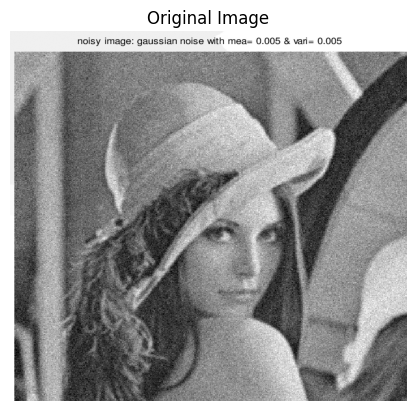

In [5]:
# Replace with uploaded image name
img = cv2.imread('input-1.webp', 0)

# Check image
print("Image Shape:", img.shape)

plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()

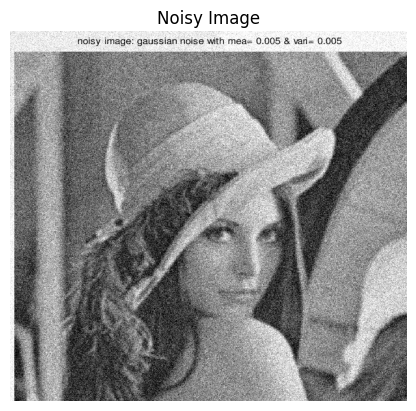

In [6]:
# Generate Gaussian Noise
gaussian_noise = np.random.normal(0, 25, img.shape)

# Add noise to image
noisy_img = img + gaussian_noise

# Clip values between 0 and 255
noisy_img = np.clip(noisy_img, 0, 255).astype(np.uint8)

# Display noisy image
plt.imshow(noisy_img, cmap='gray')
plt.title("Noisy Image")
plt.axis('off')
plt.show()

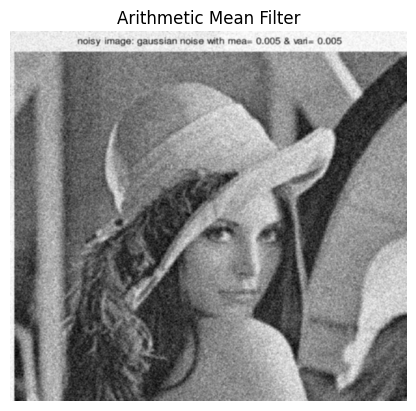

In [7]:
# Apply Arithmetic Mean Filter
mean_filter = cv2.blur(noisy_img, (3,3))

# Display result
plt.imshow(mean_filter, cmap='gray')
plt.title("Arithmetic Mean Filter")
plt.axis('off')
plt.show()

/tmp/ipykernel_2464/1567332732.py:17: RuntimeWarning: overflow encountered in scalar add
  output[i, j] = (minimum + maximum) / 2


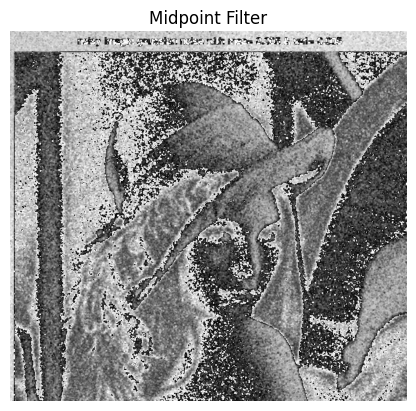

In [8]:
def midpoint_filter(image, k=3):

    pad = k // 2

    padded = np.pad(image, pad, mode='edge')

    output = np.zeros_like(image)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):

            window = padded[i:i+k, j:j+k]

            minimum = np.min(window)
            maximum = np.max(window)

            output[i, j] = (minimum + maximum) / 2

    return output.astype(np.uint8)

# Apply Midpoint Filter
midpoint_img = midpoint_filter(noisy_img)

# Display result
plt.imshow(midpoint_img, cmap='gray')
plt.title("Midpoint Filter")
plt.axis('off')
plt.show()

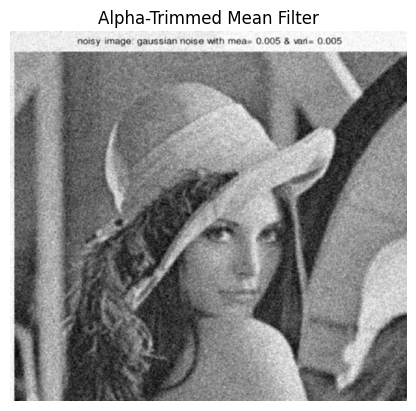

In [9]:
def alpha_trimmed_filter(image, k=3, d=2):

    pad = k // 2

    padded = np.pad(image, pad, mode='edge')

    output = np.zeros_like(image)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):

            window = padded[i:i+k, j:j+k].flatten()

            # Sort values
            window = np.sort(window)

            # Remove lowest and highest values
            trimmed = window[d//2 : len(window)-d//2]

            # Compute mean
            output[i, j] = np.mean(trimmed)

    return output.astype(np.uint8)

# Apply Alpha-Trimmed Mean Filter
alpha_trimmed_img = alpha_trimmed_filter(noisy_img)

# Display result
plt.imshow(alpha_trimmed_img, cmap='gray')
plt.title("Alpha-Trimmed Mean Filter")
plt.axis('off')
plt.show()

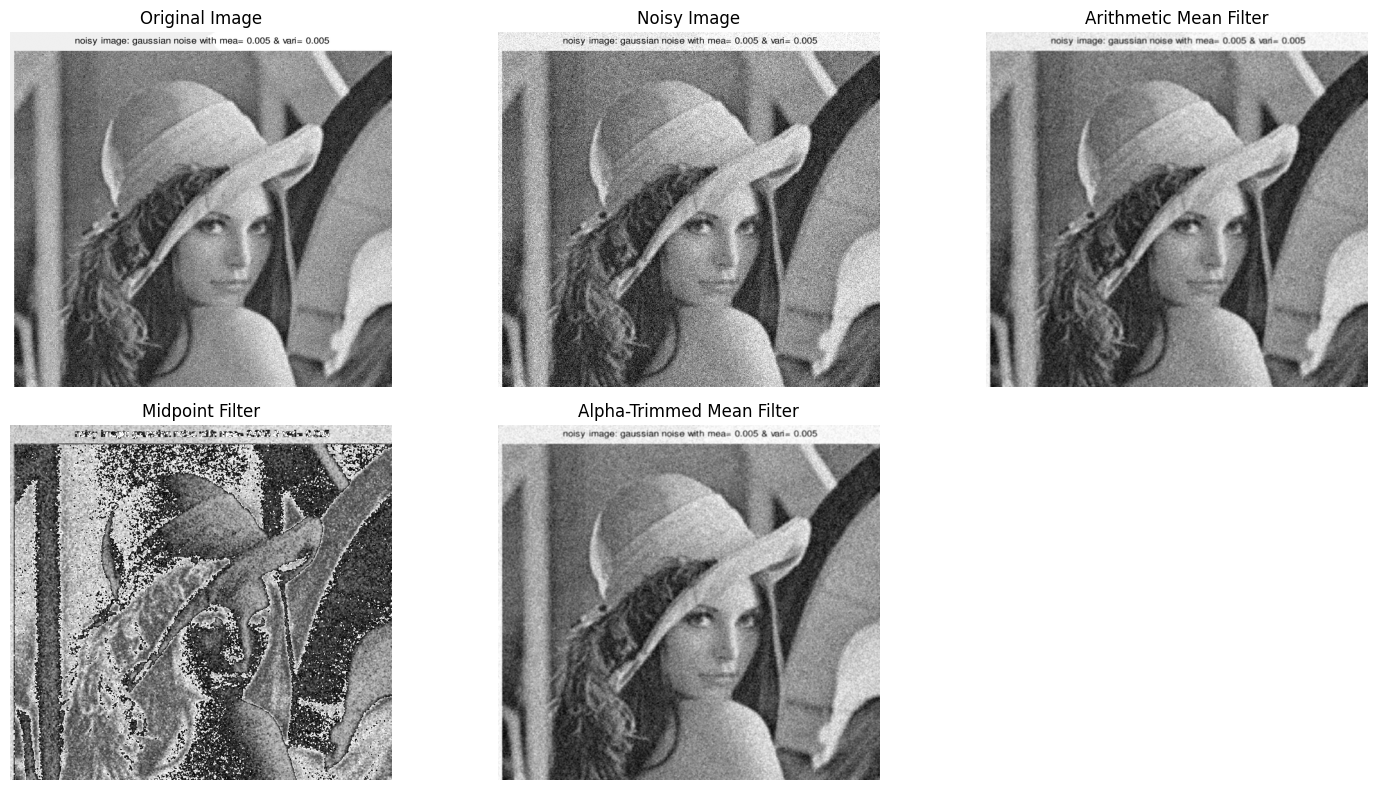

In [10]:
titles = [
    'Original Image',
    'Noisy Image',
    'Arithmetic Mean Filter',
    'Midpoint Filter',
    'Alpha-Trimmed Mean Filter'
]

images = [
    img,
    noisy_img,
    mean_filter,
    midpoint_img,
    alpha_trimmed_img
]

plt.figure(figsize=(15,8))

for i in range(len(images)):

    plt.subplot(2,3,i+1)

    plt.imshow(images[i], cmap='gray')

    plt.title(titles[i])

    plt.axis('off')

plt.tight_layout()
plt.show()